In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

# Color Palette
ColorBlue   =  ["#00B4FA","#00A3E9","#0093D9","#0082C8","#0071B7","#0061A7","#005096","#003F85","#002F75","#001E64"]
ColorRed    =  ["#FA5050","#F24747","#EA3E3E","#E33535","#DB2C2C","#D32424","#CB1B1B","#C41212","#BC0909","#B40000"]
ColorGreen  =  ["#96D250","#85C850","#75BE50","#64B450","#53AA50","#43A050","#329650","#218C50","#118250","#007850"]
ColorYellow =  ["#FAFA00","#FAE903","#FAD907","#FAC80A","#FAB70D","#FAA711","#FA9614","#FA8517","#FA751B","#FA641E"]
ColorPurple =  ["#FA82FA","#E774E8","#D465D6","#C157C5","#AE48B3","#9C3AA1","#892B8F","#761D7E","#630E6C","#50005A"]
ColorGray   =  ["#B4B4B4","#A4A4A4","#959595","#858585","#767676","#666666","#575757","#474747","#383838","#282828"]

### 参数设置

In [2]:
N = 1000
dt = 0.01 # ms
Time = 1000.0 # ms
T = int(Time/dt)
V_rest = -70.0 # Resting potential, unit: mV
V_reset = -60.0 # Reset potential, unit: mV
threshold = -50.0 # Threshold potential, unit: mV
t_ref = 2.0 # Refractory period, unit: ms
ref_length = int(t_ref/dt)
C = 500.0 # Capacitance, unit: pF
g_L = 25.0 # Leakage conductance, unit: nS
g_ampa = 2.0 # AMPA conductance, unit: nS
tau_ampa = 2.0 # unit: ms
V_E = 0.0 # unit: mV

noise_freqs = np.arange(1.5,3.05,0.05) # kHz
spike_freqs = np.zeros(len(noise_freqs))

### 响应函数

In [ ]:
rng = np.random.default_rng()
for i in range(len(noise_freqs)):
    p_noise = noise_freqs[i] * dt
    spikes_external = rng.binomial(1, p_noise, (N, T))
    V = np.full((N, T), V_rest)
    not_refractory = np.ones((N, T))
    spikes = np.zeros((N, T))
    I_ext = np.zeros((N, T))
    I_rec = np.zeros((N, T))
    p = 0.0
    W = sparse.csr_matrix(rng.random((N, N)) < p,dtype=np.float64)
    S_ampa_ext = np.zeros((N, T))
    S_ampa_rec = np.zeros((N, T))
    for t in range(1, T):
        V[:,t] = V[:,t-1] + dt/C*(-g_L*(V[:,t-1]-V_rest)-(I_ext[:,t-1]+I_rec[:,t-1])*not_refractory[:,t-1])
        spikes[V[:,t] > threshold, t] = 1
        V[spikes[:,t] == 1,t-1] = 0
        V[spikes[:,t] == 1,t] = V_reset
        refractory_steps = np.minimum(t+ref_length, T)
        not_refractory[spikes[:,t]==1,t:refractory_steps] = 0
        S_ampa_ext[:,t] = S_ampa_ext[:,t-1]-S_ampa_ext[:,t-1]/tau_ampa*dt + spikes_external[:,t-1]
        I_ext[:, t] = g_ampa * (V[:,t] - V_E) * S_ampa_ext[:,t]
        S_ampa_rec[:, t] = S_ampa_rec[:, t-1] - S_ampa_rec[:, t-1] / tau_ampa * dt + spikes[:, t-1]
        I_rec[:, t] = g_ampa * (V[:, t] - V_E) * (W @ S_ampa_rec[:, t])
    spike_freqs[i] = np.sum(spikes, axis=1).mean(axis=0) / Time * 1000
np.save("Noise Frequencies.npy", noise_freqs)
np.save("Spike Frequencies.npy", spike_freqs)

### 理论预测

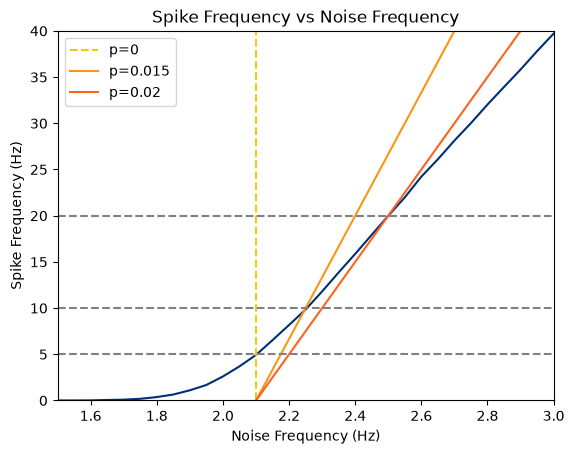

In [ ]:
noise_freqs = np.load("Noise Frequencies.npy")
spike_freqs = np.load("Spike Frequencies.npy")
z = 2.1 # KHz
p_1 = 0.015
p_2 = 0.020
N = 1000
def line_1(x: float) -> float:
    return (x - z)*1000 / (p_1 * N)
def line_2(x: float) -> float:
    return (x - z)*1000 / (p_2 * N)
plt.plot(noise_freqs, spike_freqs,color=ColorBlue[8])
plt.vlines(z, 0, 50, color=ColorYellow[3], linestyles="dashed", label="p=0")
plt.plot(noise_freqs, line_1(noise_freqs),color=ColorYellow[6], label="p=0.015")
plt.plot(noise_freqs, line_2(noise_freqs),color=ColorYellow[9], label="p=0.02")
plt.xlim([1.5, 3.0])
plt.ylim([0, 40])
plt.xlabel("Noise Frequency (Hz)")
plt.ylabel("Spike Frequency (Hz)")
plt.title("Spike Frequency vs Noise Frequency")
plt.hlines(5, 1.5, 3.0, colors="gray", linestyles="dashed")
plt.hlines(10, 1.5, 3.0, colors="gray", linestyles="dashed")
plt.hlines(20, 1.5, 3.0, colors="gray", linestyles="dashed")
plt.legend()

### 实验验证

Text(0, 0.5, 'Spike Frequency (Hz)')

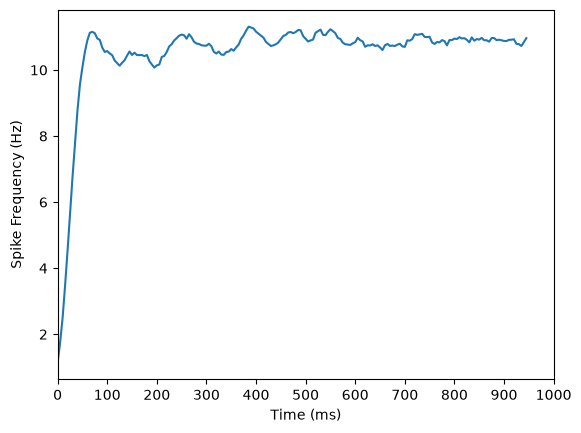

In [ ]:
Rep = 10
p_noise = 2.1 * dt
p = 0.015

window_size = int(50 / dt)
shift_size = int(5 / dt)
x = np.arange(0, T - window_size, shift_size)
spike_freqs = np.zeros((Rep,len(x)))

for rep in range(Rep):
    spikes_external = rng.binomial(1, p_noise, (N, T))
    V = np.full((N, T), V_rest)
    not_refractory = np.ones((N, T))
    spikes = np.zeros((N, T))
    I_ext = np.zeros((N, T))
    I_rec = np.zeros((N, T))
    W = sparse.csr_matrix(rng.random((N, N)) < p,dtype=np.float64)
    S_ampa_ext = np.zeros((N, T))
    S_ampa_rec = np.zeros((N, T))
    for t in range(1, T):
        V[:,t] = V[:,t-1] + dt/C*(-g_L*(V[:,t-1]-V_rest)-(I_ext[:,t-1]+I_rec[:,t-1])*not_refractory[:,t-1])
        spikes[V[:,t] > threshold, t] = 1
        V[spikes[:,t] == 1,t-1] = 0
        V[spikes[:,t] == 1,t] = V_reset
        refractory_steps = np.minimum(t+ref_length, T)
        not_refractory[spikes[:,t]==1,t:refractory_steps] = 0
        S_ampa_ext[:,t] = S_ampa_ext[:,t-1]-S_ampa_ext[:,t-1]/tau_ampa*dt + spikes_external[:,t-1]
        I_ext[:, t] = g_ampa * (V[:,t] - V_E) * S_ampa_ext[:,t]
        S_ampa_rec[:, t] = S_ampa_rec[:, t-1] - S_ampa_rec[:, t-1] / tau_ampa * dt + spikes[:, t-1]
        I_rec[:, t] = g_ampa * (V[:, t] - V_E) * (W @ S_ampa_rec[:, t])
    for i, t in enumerate(x):
        spike_freqs[rep,i] = np.sum(spikes[:, t:t+window_size], axis=1).mean(axis=0) / 50 * 1000

plt.plot(x, np.mean(spike_freqs,axis=0))
plt.xlim([0,T])
plt.xticks(np.arange(0, T+1, int(T/10)),np.arange(0,1001,100))
plt.xlabel("Time (ms)")
plt.ylabel("Spike Frequency (Hz)")

### 扰动实验